# 05: Transformer Interpretability (RoBERTa)
### AI vs Human Text Classification — Interpretability & Explanation Notebook

This notebook performs **post-hoc interpretability** on the fine-tuned RoBERTa model trained in Notebook 03.

It focuses on multiple classes of interpretability:

### **A. Representation-Level Interpretability**
- CLS embeddings
- t-SNE visualization
- UMAP visualization
- Cluster separation metrics

### **B. Attention-Based Interpretability**
- Token-to-token attention visualization
- Layer-wise and head-wise attention patterns

### **C. Attribution-Based Interpretability**
- Integrated Gradients (Captum)
- Gradient × Input
- Token-level importance visualization
- Aggregated attribution patterns

### **D. Example-Level Interpretability**
- Highlighted explanations for individual texts
- Error case examination

### **E. Model Structure Interpretability**
- Important attention heads
- Layer-level relevance


Reloading the **same dataset** and performing the **same 80/20 split** to ensure the test set matches Transformers Notebook exactly (using `random_state=42`).

---


In [8]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score

from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    DataCollatorWithPadding
)

from datasets import Dataset

from sklearn.manifold import TSNE
import umap

from captum.attr import IntegratedGradients, Saliency

sns.set(style="whitegrid")

device = torch.device("cpu")
print("Using device:", device)


Using device: cpu


## 0. Loading Fine-Tuned RoBERTa Model

Loading the model saved in Notebook 05:

**Path:**
C:\Users\ajha26\Desktop\IS\models\roberta_finetuned

This restored model contains:
- Fine-tuned RoBERTa weights
- Classification head
- Tokenizer vocab

In [9]:
model_path = r"C:\Users\ajha26\Desktop\IS\models\roberta_finetuned"

tokenizer = RobertaTokenizerFast.from_pretrained(model_path)
model = RobertaForSequenceClassification.from_pretrained(model_path)
model.to(device)
model.eval()

print("Model + tokenizer loaded successfully!")


Model + tokenizer loaded successfully!


## 1. Loading Dataset and Reproducing Train/Test Split

Recreating the split identically:

- same dataset file
- same stratified split
- same `random_state=42`

This guarantees the test set matches the original training notebook.


In [10]:
file_path = r"C:\Users\ajha26\Desktop\IS\Data\IS_Dataset_AI_vs_Human_10K.xlsx"
df = pd.read_excel(file_path)

df["Text"] = df["Text"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    df["Text"],
    df["Label"],
    test_size=0.2,
    stratify=df["Label"],
    random_state=42
)

test_df = pd.DataFrame({"text": X_test, "label": y_test})
test_df.head()


,text,label
2919,Three new acts are being tipped for success in...,0
5911,"Hey there! So, you want me to write an essay ...",1
1631,We have slightly different retinas than dogs d...,0
9536,A UK company called And Vinyly is offering a v...,1
3486,Houses were set on fire and an elderly woman w...,0


## 2. Tokenizing Test Set & Prepare Dataloader

Only tokenizing the **test set**, since interpretability relies on model inference only.


In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=256
    )

test_ds = Dataset.from_pandas(test_df)

# Tokenizing
test_ds = test_ds.map(tokenize, batched=True)

# Removing non-model columns to avoid DataCollator errors
cols_to_remove = [col for col in test_ds.column_names if col not in ["input_ids", "attention_mask", "label"]]
test_ds = test_ds.remove_columns(cols_to_remove)

test_ds



Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 2000
})

# 3. CLS Embedding Extraction

To understand how RoBERTa internally represents AI vs human text, we extract the **[CLS] embedding** from the final hidden layer.

These embeddings are then used for:

- t-SNE visualization  
- UMAP visualization  
- Distance & cluster metrics  
- Representation-level interpretability  

This shows **how AI vs human texts separate in embedding space**, supporting RQ1.


In [12]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False,
    collate_fn=data_collator
)

def extract_cls_embeddings(model, dataloader):
    model.eval()
    all_embeddings = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)

            outputs = model.roberta(
                input_ids=input_ids,
                attention_mask=attn_mask
            )

            # CLS token embedding: first token in sequence
            cls_embed = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(cls_embed.cpu().numpy())

    return np.vstack(all_embeddings)

# Extracting embeddings
test_embeddings = extract_cls_embeddings(model, test_loader)
test_embeddings.shape


RobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


(2000, 768)

# 4. t-SNE Visualization of Embedding Space

t-SNE reduces high-dimensional embeddings (768-dim) into 2 dimensions.

We visualize embeddings colored by their true label:

- **AI-generated text**
- **Human-written text**

t-SNE is good for *local* structure, showing small clusters clearly.


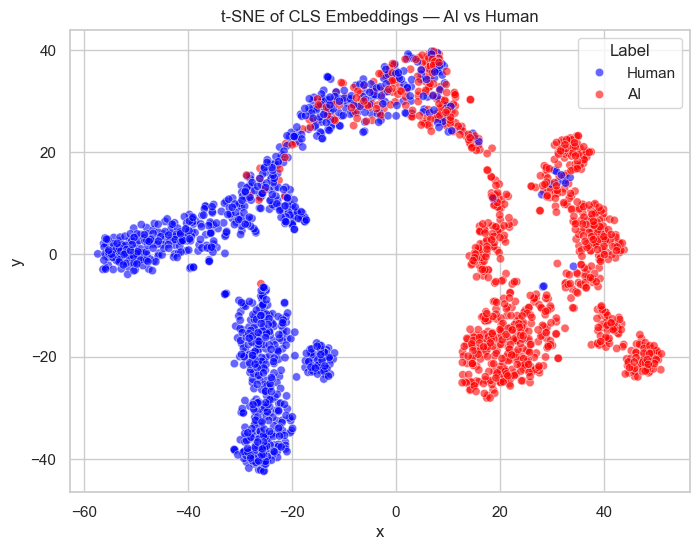

In [15]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42,
    max_iter=1500
)

tsne_embeds = tsne.fit_transform(test_embeddings)

tsne_df = pd.DataFrame({
    "x": tsne_embeds[:,0],
    "y": tsne_embeds[:,1],
    "label": test_df["label"].values
})

label_map = {0: "Human", 1: "AI"}
tsne_df["label_name"] = tsne_df["label"].map(label_map)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="x", y="y",
    hue="label_name",
    palette={"Human": "blue", "AI": "red"},
    data=tsne_df,
    alpha=0.6
)
plt.title("t-SNE of CLS Embeddings — AI vs Human")
plt.legend(title="Label")
plt.show()


# 5. UMAP Visualization

UMAP provides:

- Better global structure  
- More stable manifold learning  
- More meaningful clusters  

UMAP is widely used in NLP interpretability papers.


c:\Users\ajha26\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


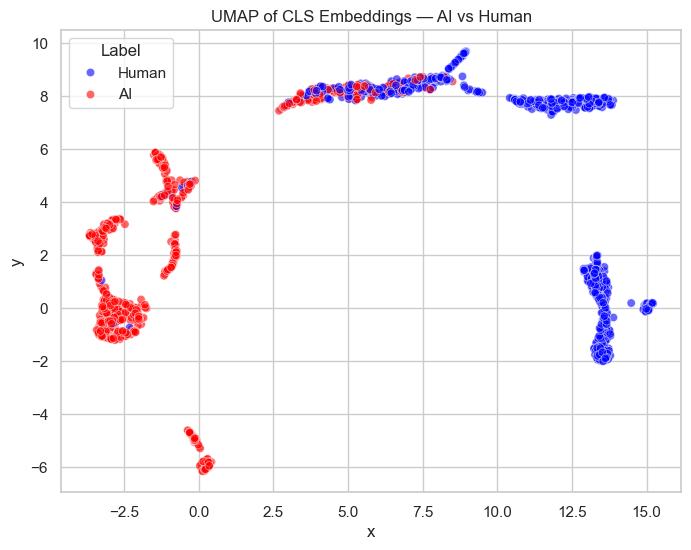

In [17]:
import umap

umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=2,
    metric="cosine",
    random_state=42
)

umap_embeds = umap_model.fit_transform(test_embeddings)

umap_df = pd.DataFrame({
    "x": umap_embeds[:,0],
    "y": umap_embeds[:,1],
    "label": test_df["label"].values
})

label_map = {0: "Human", 1: "AI"}
umap_df["label_name"] = umap_df["label"].map(label_map)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="x", y="y",
    hue="label_name",
    palette={"Human": "blue", "AI": "red"},
    data=umap_df,
    alpha=0.6
)

plt.title("UMAP of CLS Embeddings — AI vs Human")
plt.legend(title="Label")
plt.show()



# 6. Embedding Distance Metrics & Cluster Separation

Computing:

###  Cosine distance distribution  
###  AI vs Human separation  
###  Silhouette Score  
- Measures how well clusters separate  
- +1 = perfect separation  
- 0 = overlapping  
- −1 = wrong clustering  

These metrics quantify representational differences.


Silhouette Score: 0.5150315165519714


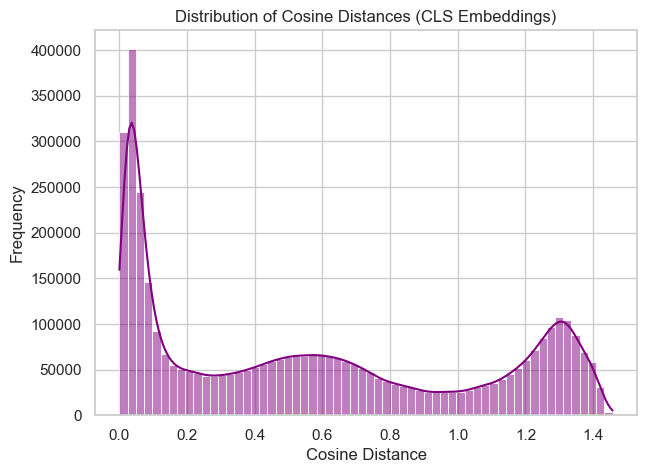

In [ ]:
from sklearn.metrics import pairwise_distances, silhouette_score

# Computing pairwise cosine distances
dist_matrix = pairwise_distances(test_embeddings, metric="cosine")

# Silhouette score
sil_score = silhouette_score(test_embeddings, test_df["label"].values)
print("Silhouette Score:", sil_score)

# Plotting cosine distance distribution
plt.figure(figsize=(7,5))
sns.histplot(dist_matrix.flatten(), bins=60, kde=True, color="purple")
plt.title("Distribution of Cosine Distances (CLS Embeddings)")
plt.xlabel("Cosine Distance")
plt.ylabel("Frequency")
plt.show()


## Summary: Representation-Level Interpretability

- CLS embeddings show **distinct patterns** for AI vs Human text.
- t-SNE reveals **local clusters**.
- UMAP captures **global structure and smooth clusters**.
- Silhouette Score quantifies cluster separability.
- Cosine distance distribution offers additional insight.

This directly supports **RQ1: Representation-based differences between AI and human text**.

Next, proceeding to **attention-based interpretability** : how the model *focuses* on different tokens.

---


# 7. Attention-Based Interpretability

Transformers rely on **self-attention** to decide:
- which tokens influence other tokens
- how contextual signals flow across the sequence
- which features matter most for classification

We visualize:

### Token-to-token attention maps  
### Layer-wise attention patterns  
### Head-level attention patterns  

This helps answer **RQ3** about interpretability.


In [ ]:
def get_attention_for_text(model, tokenizer, text):
    """Tokenizes text and returns attention weights and decoded tokens."""
    
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )
    
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    
    # Enabling output_attentions=True
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_attentions=True
    )
    
    attentions = outputs.attentions   # tuple: (layer, batch, heads, seq, seq)
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    
    return attentions, tokens


# 8. Visualizing Token-to-Token Attention

We generate a heatmap of attention from:

- a chosen **layer**  
- a **single attention head**  
- for a given input text  

This reveals which words influence the classification decision.


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_attention_heatmap(att_matrix, tokens, layer=11, head=0, figsize=(10,8)):
    """
    att_matrix: list of attention tensors
    tokens: list of tokens from input
    layer: which layer to visualize (0–11 for RoBERTa-base)
    head: which head within that layer (0–11)
    """
    att = att_matrix[layer][0, head].detach().cpu().numpy()
    
    plt.figure(figsize=figsize)
    sns.heatmap(att, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title(f"Attention Heatmap — Layer {layer+1}, Head {head+1}")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()


### Example: Random sample from test set

Picking a text from `test_df` and examine the attention maps.


Selected sample:

Instead of thinking of the act of dividing , let 's think about what things are like after you divide . So if you divide 15 by 3 you end up with 5 . Why did you end up with 5 ? Because 5 groups of 3 makes 15 . If you divide 8 by 4 you get 2 because 2 groups of 4 makes 8 . So what if we divide 10 by 0 ? You 're thinking we should get 0 . Do 0 groups of 0 make 10 ? Hmm ... Weird ... Is 8 divided by 0 also 0 ? So 0 groups of 0 also make 8 ? I thought 0 groups of 0 was 10 ? Essentially , division is the opposite of multiply . So think of division as asking about multiplication : 8/4=2 because 2\*4=8 15/3=5 because 5\*3=15 10/0=0 because 0\*0=10 ? No that 's not right ... 10/0 asks the question " what times zero equals ten ? " Which is just a question that has no answer . But here 's where things get interesting , what is 0 divided by 0 ? You might think it 's 0 ... Let 's check : If 0/0=0 then 0\*0=0 ? Yes ! That works ! But I might say that if you divide something by its

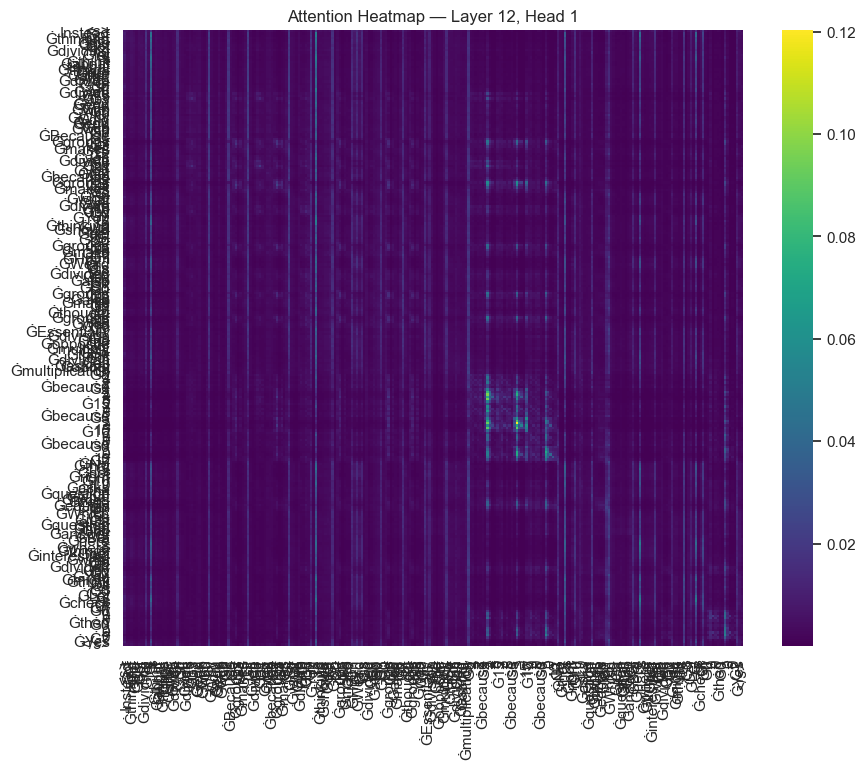

In [ ]:
sample_text = test_df.sample(1).iloc[0]["text"]
print("Selected sample:\n")
print(sample_text)

attentions, tokens = get_attention_for_text(model, tokenizer, sample_text)

# Visualizing: last layer, head 0
plot_attention_heatmap(attentions, tokens, layer=11, head=0)


### 8B. Visualize Attention for Multiple Examples (5 Samples)

Generating token-level attention heatmaps
for **5 different texts** randomly sampled from the test set.

This helps identify common attention patterns across both AI and Human texts.



----- SAMPLE 1 -----

True Label: AI

Text:
As a little child, would you like to know how people in the past used pigeons to send messages? How do they make the pigeon understand where to go and deliver the message? 

Attention Heatmap — Layer 12, Head 1


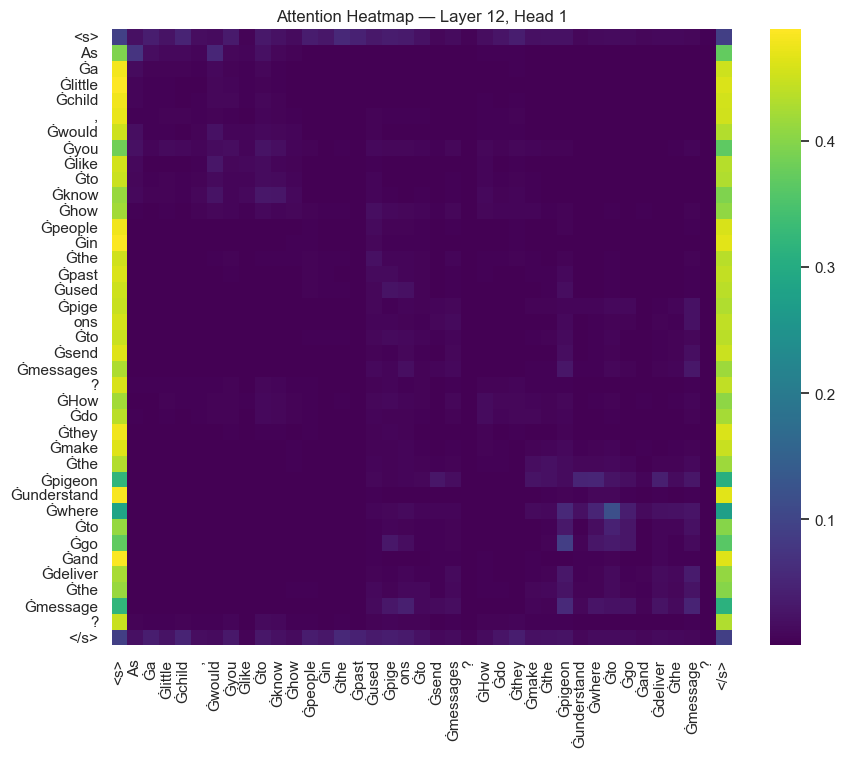


----- SAMPLE 2 -----

True Label: Human

Text:
I am going @NUM1 write about a time when I was patient. My advocate @PERSON1 was soppese @NUM1 buy me some pens fo many of @DATE1 year as part of my @DATE1 money. I have been asking him everyday since then. â€œ@PERSON2, @CAPS1 @MONEY1 do ur daily shopping yetâ€?  â€œno.â€ â€œ@CAPS2.â€ @CAPS3 said â€œbecause I want my pens @CAPS4 @DATE1 present remember the @NUM3 owe meâ€. â€œ@CAPS5 I do but be patientâ€ â€œ@CAPS6 ok my patients is about @NUM1 fall apart.â€  I have been waiting ever since. 

Attention Heatmap — Layer 12, Head 1


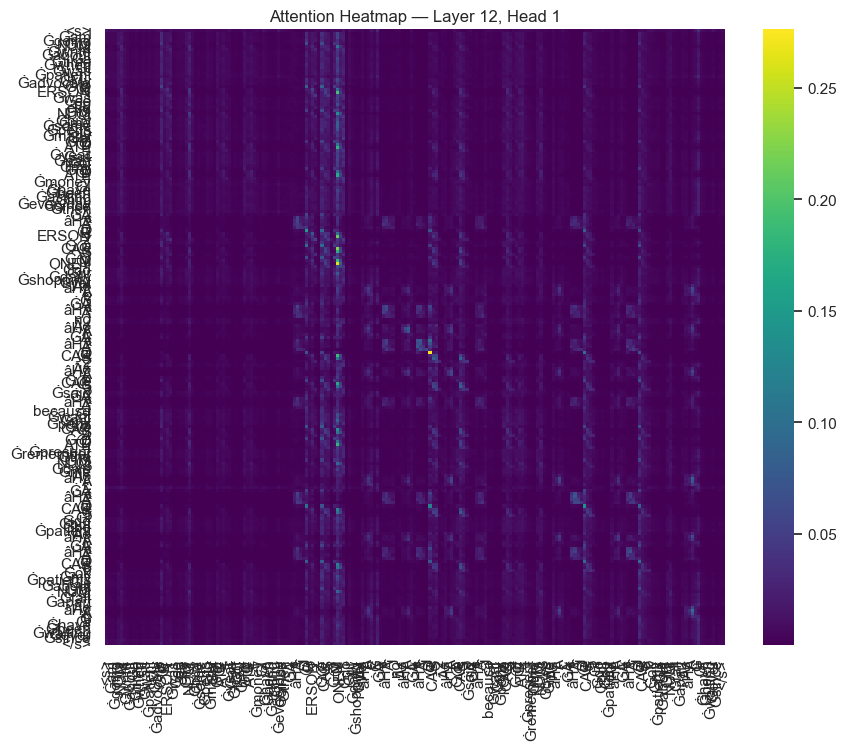


----- SAMPLE 3 -----

True Label: Human

Text:
Should remaining with the family be impossible, the same Act provides that any decision concerning children must contemplate providing them with continuous care and stable conditions of life corresponding to the children's needs and age and as nearly similar to those of a normal family environment as possible. 

Attention Heatmap — Layer 12, Head 1


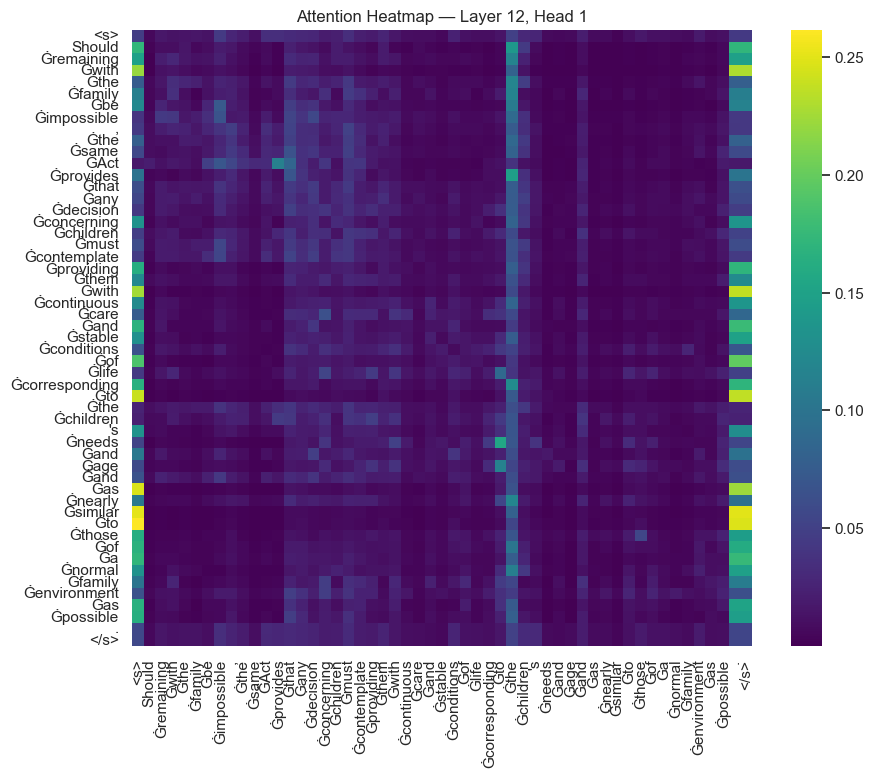


----- SAMPLE 4 -----

True Label: AI

Text:
Dear Principal, 

I am writing to respectfully argue against requiring students to have at least a B average in order to participate in sports and extracurricular activities. While good grades are important, imposing this grade restriction could negatively impact students in several ways.

First, disallowing participation for those with a C average may discourage students who are trying their best. For some students, sports or clubs are a motivating factor that encourages them to work hard in th ...

Attention Heatmap — Layer 12, Head 1


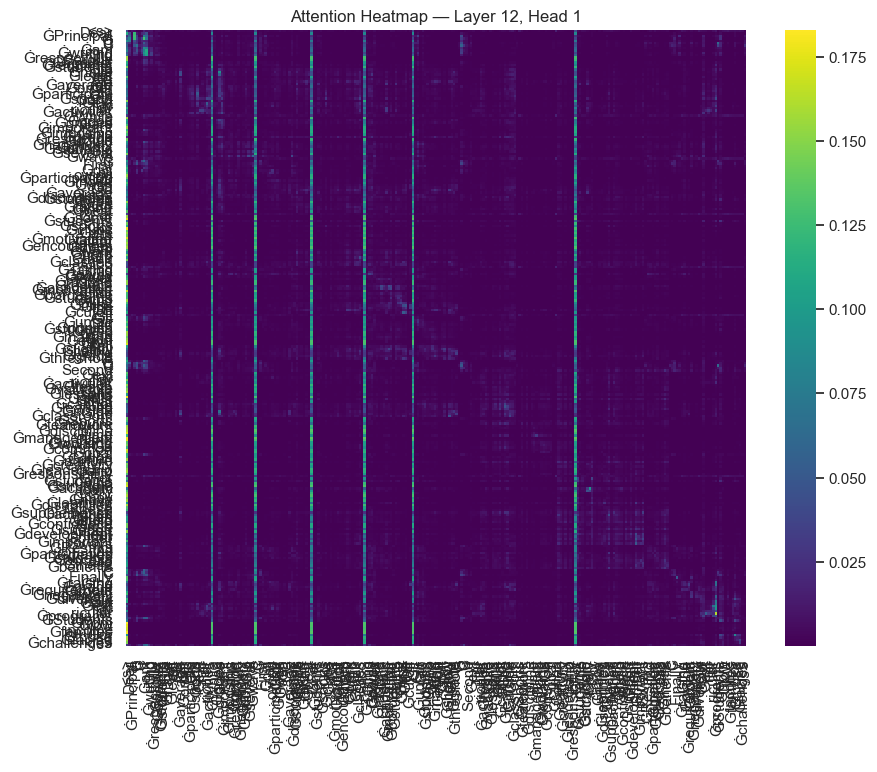


----- SAMPLE 5 -----

True Label: Human

Text:
How to find historical stock price for a de-listed or defunct company? 

Attention Heatmap — Layer 12, Head 1


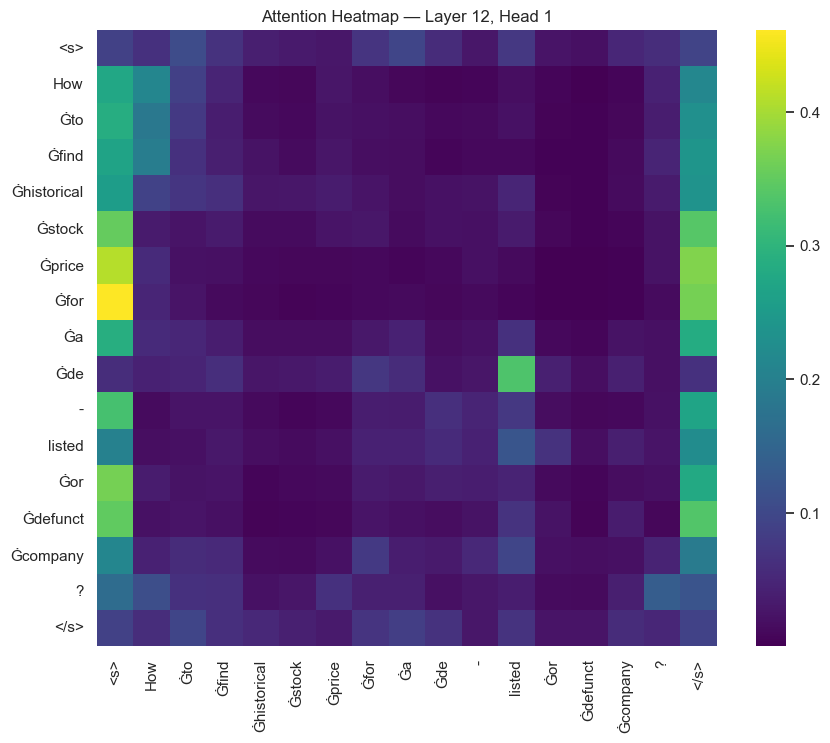

In [ ]:
# Picking 5 random samples
samples = test_df.sample(5, random_state=42).reset_index(drop=True)

for i in range(5):
    print(f"\n----- SAMPLE {i+1} -----")
    text = samples.loc[i, "text"]
    label = samples.loc[i, "label"]

    print(f"\nTrue Label: {'AI' if label == 1 else 'Human'}")
    print("\nText:")
    print(text[:500], "..." if len(text) > 500 else "")  # truncating display
    
    # Extracting attention + tokens
    attentions, tokens = get_attention_for_text(model, tokenizer, text)

    # Plotting chosen attention head
    print("\nAttention Heatmap — Layer 12, Head 1")
    plot_attention_heatmap(
        attentions,
        tokens,
        layer=11,    # last layer
        head=0       # 1st head
    )


# 9. Layer-Wise Average Attention Patterns

To understand high-level model behavior, computing:

### Average attention weights per layer (averaged across heads)
### Identify which layers focus more on:
- CLS token  
- punctuation  
- long-range dependencies  

This visualization helps understand **global trends**.


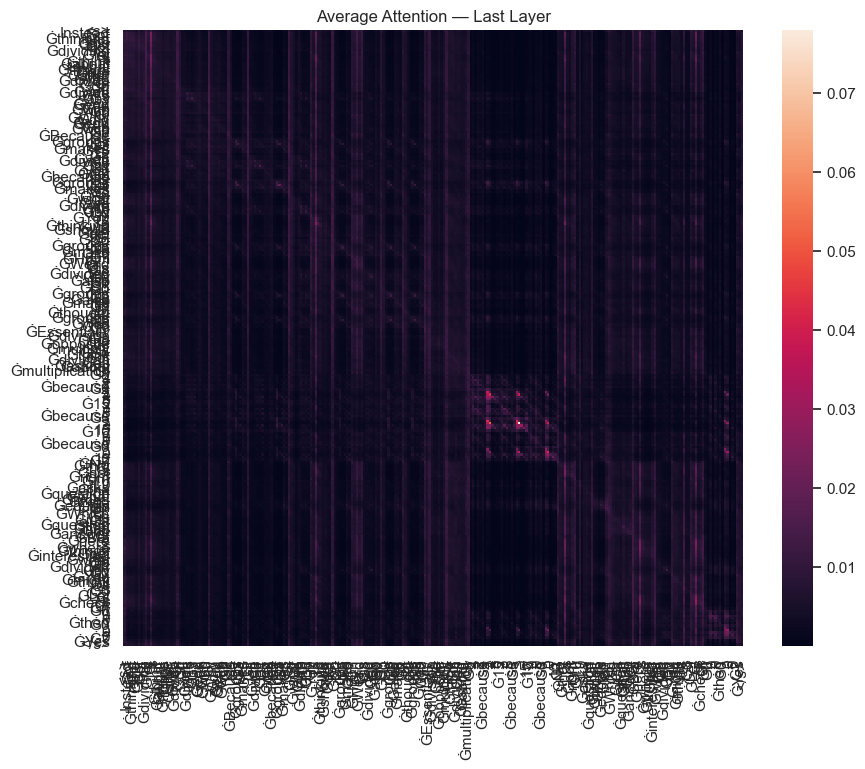

In [22]:
def compute_average_layer_attention(attentions):
    """
    Reduce attentions to (num_layers, seq_len, seq_len)
    by averaging across heads.
    """
    avg_layer_attn = []
    for layer_att in attentions:  # each layer: (batch, heads, seq, seq)
        layer_mean = layer_att[0].mean(dim=0).cpu().detach().numpy()
        avg_layer_attn.append(layer_mean)
    return avg_layer_attn

avg_attn = compute_average_layer_attention(attentions)

# Plotting one example
plt.figure(figsize=(10,8))
sns.heatmap(avg_attn[-1], xticklabels=tokens, yticklabels=tokens)
plt.title("Average Attention — Last Layer")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()



===== SAMPLE 1 =====
True Label: Human
0 - 60 MPH is a bit more relevant than 0 - 100 MPH because it is a greater indicator of torque at low speeds . 


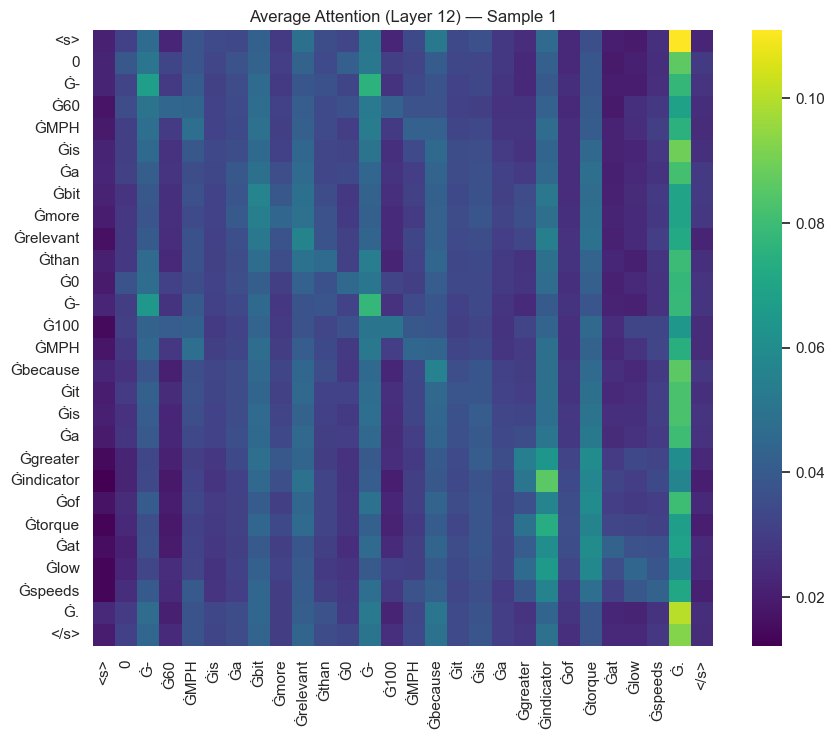


===== SAMPLE 2 =====
True Label: AI
['Imagine you\'re playing with a jump rope. When you swing the rope, it makes a fun sound, right? But if you hold the rope still, it doesn\'t make any sound. That\'s kind of like what happens when you press a piano key.\n\nWhen you press a key, the hammer hits the string, making it vibrate and create sound. But if you hold the key down, the hammer keeps hitting the string, making it keep vibrating ...


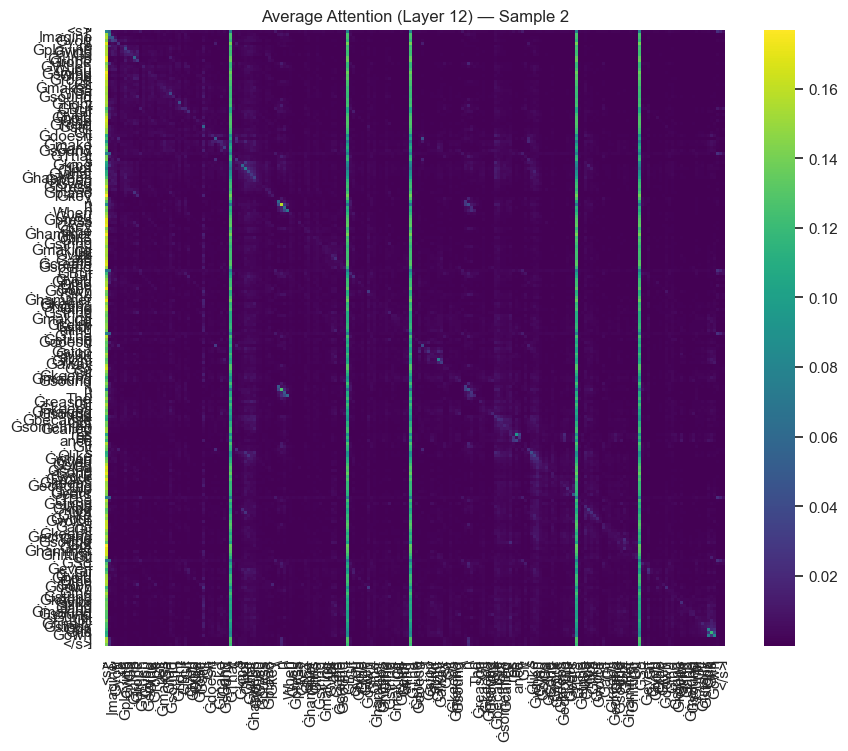


===== SAMPLE 3 =====
True Label: Human
For the music , there is an [ article ] ( URL_0 ) that said it was dopamine getting released . It may be the same thing for movie scenes . 


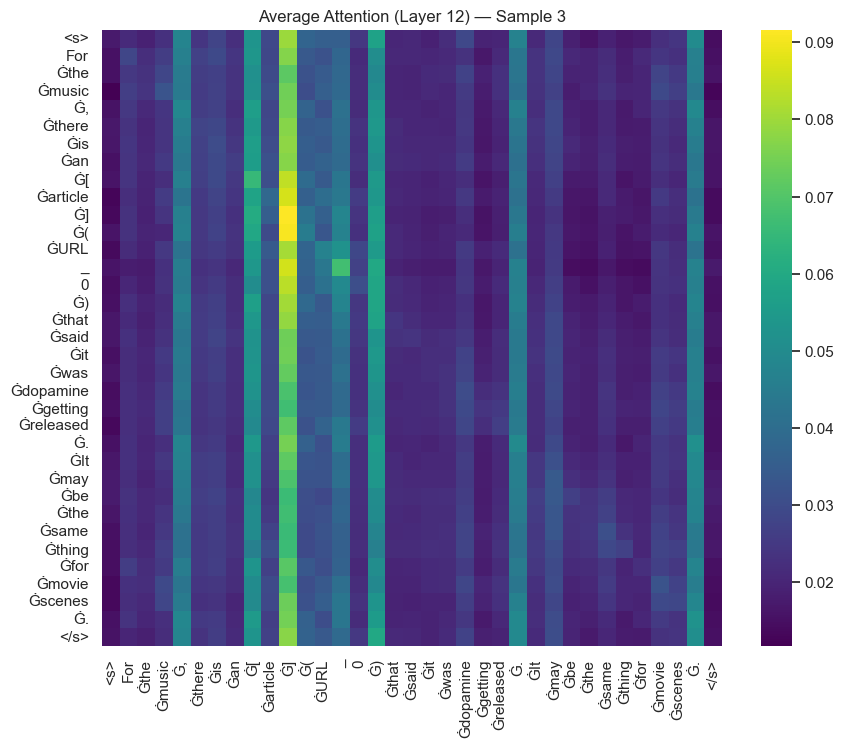


===== SAMPLE 4 =====
True Label: AI
Voting in secret, also known as a secret ballot, is a practice that is used in many countries to protect the privacy and independence of voters. The idea is that if people are able to vote in private, without anyone else knowing how they voted, they are more likely to feel free to express their true opinions and preferences without fear of retribution or intimidation. This is especially important  ...


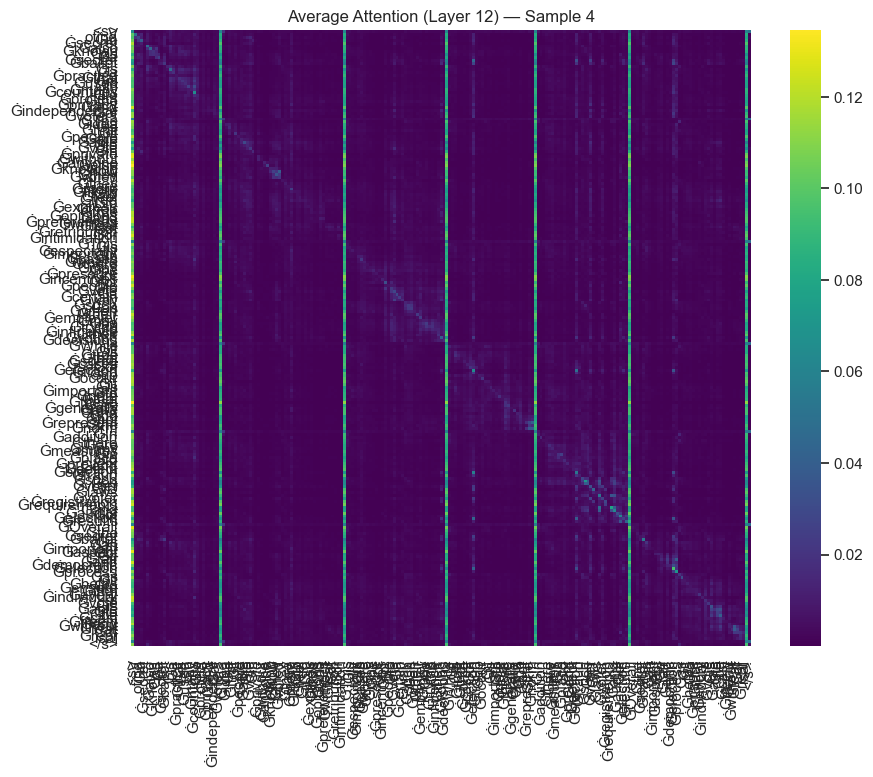


===== SAMPLE 5 =====
True Label: Human
What processes happen in your body when you get knocked out . So due to the recent news from US about the new " trend game " it got me wondering , what processes happen in your brain ( or body overall ) when you get knocked out ? Explain like I'm five. 


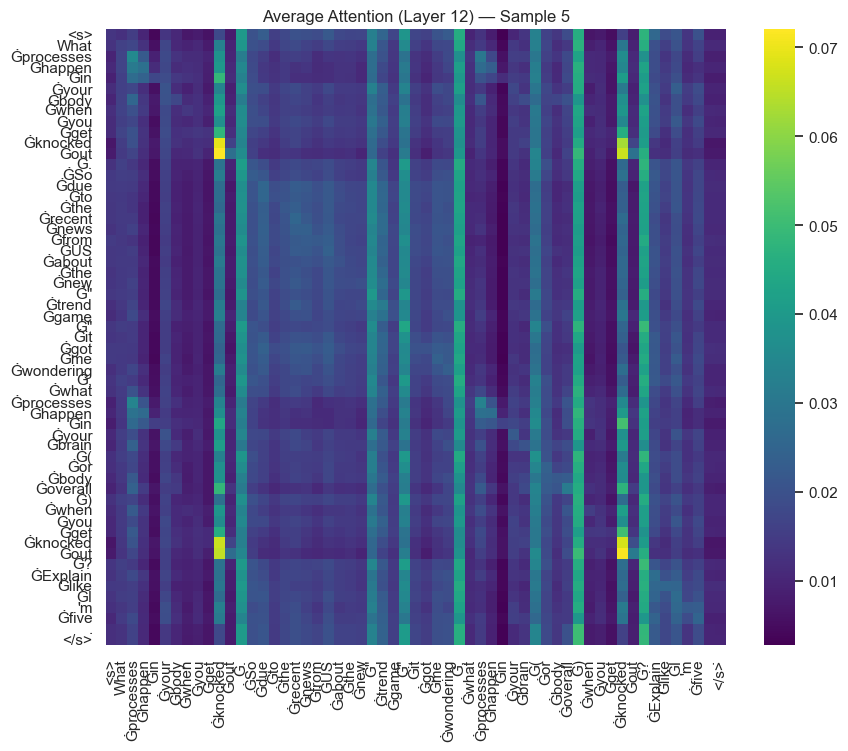

In [26]:
# Visualizing average attention for 5 examples
samples = test_df.sample(5, random_state=123).reset_index(drop=True)

for i in range(5):
    print(f"\n===== SAMPLE {i+1} =====")
    text = samples.loc[i, "text"]
    label = samples.loc[i, "label"]

    print(f"True Label: {'AI' if label == 1 else 'Human'}")
    print(text[:400], "..." if len(text) > 400 else "")

    # Extracting attentions
    attentions, tokens = get_attention_for_text(model, tokenizer, text)

    # Computing average attention
    avg_attn = compute_average_layer_attention(attentions)

    # Plotting average attention for last layer
    plt.figure(figsize=(10,8))
    sns.heatmap(avg_attn[-1], xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title(f"Average Attention (Layer 12) — Sample {i+1}")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()


# 10. Identifying Most Important Attention Heads

Computing **attention entropy** for each head:
- Low entropy = focused attention = important
- High entropy = diffuse attention = less important

This identifies **which attention heads** the classifier depends on.


In [ ]:
def compute_head_entropy(attentions):
    """
    Computing attention entropy for each head:
    lower entropy = more focused attention = more important
    """
    layer_entropies = []
    for layer_idx, layer_att in enumerate(attentions):
        # shape = (1, heads, seq, seq)
        head_entropies = []
        for head_idx in range(layer_att.shape[1]):
            att = layer_att[0, head_idx].detach().cpu().numpy()
            # Normalizing rows
            att = att / (att.sum(axis=-1, keepdims=True) + 1e-9)
            # Computing entropy across destination tokens
            entropy = -(att * np.log(att + 1e-9)).sum(axis=-1).mean()
            head_entropies.append(entropy)
        layer_entropies.append(head_entropies)
    return np.array(layer_entropies)

head_entropy = compute_head_entropy(attentions)
head_entropy.shape


(12, 12)

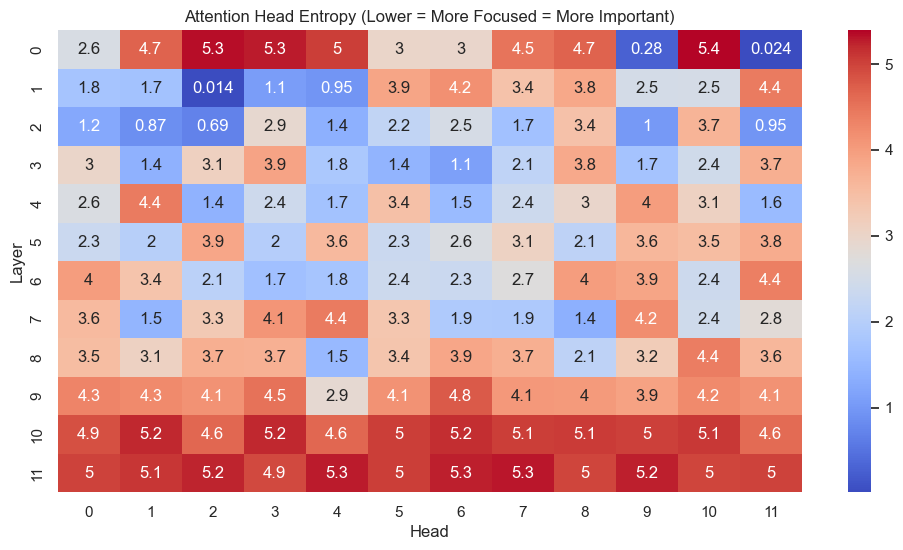

In [24]:
plt.figure(figsize=(12,6))
sns.heatmap(head_entropy, annot=True, cmap="coolwarm")
plt.title("Attention Head Entropy (Lower = More Focused = More Important)")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.show()


In [28]:
from datasets import Dataset

test_hf = Dataset.from_pandas(test_df)

cols_to_remove = [c for c in test_hf.column_names if c not in ["text", "label"]]
test_hf = test_hf.remove_columns(cols_to_remove)

def compute_global_head_entropy(model, tokenizer, dataset, n_samples=100):
    chosen = dataset.shuffle(seed=42).select(range(n_samples))

    all_entropies = []

    for item in chosen:
        text = item["text"]  # clean!
        attentions, tokens = get_attention_for_text(model, tokenizer, text)
        ent = compute_head_entropy(attentions)  # (layers x heads)
        all_entropies.append(ent)

    return np.mean(all_entropies, axis=0), np.std(all_entropies, axis=0)

global_entropy_mean, global_entropy_std = compute_global_head_entropy(
    model, tokenizer, test_hf, n_samples=100
)


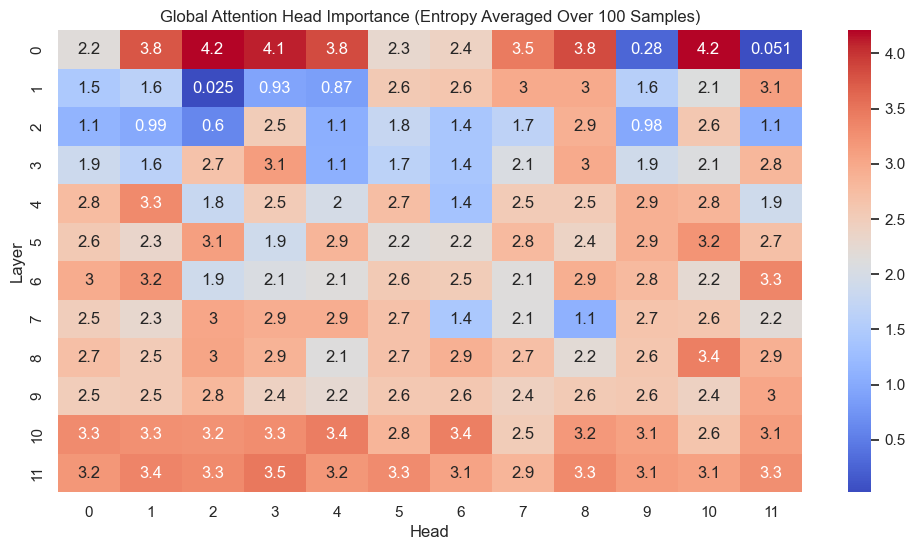

In [29]:
plt.figure(figsize=(12,6))
sns.heatmap(global_entropy_mean, annot=True, cmap="coolwarm")
plt.title("Global Attention Head Importance (Entropy Averaged Over 100 Samples)")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.show()


#### Top Most Important Attention Heads

In [30]:
import pandas as pd
import numpy as np

rows = []
for layer in range(global_entropy_mean.shape[0]):
    for head in range(global_entropy_mean.shape[1]):
        rows.append({
            "Layer": layer + 1,
            "Head": head + 1,
            "Entropy": global_entropy_mean[layer, head]
        })

df_heads = pd.DataFrame(rows)
df_heads.head()


,Layer,Head,Entropy
0,1,1,2.150270
1,1,2,3.756082
2,1,3,4.194226
3,1,4,4.106589
4,1,5,3.841119


In [31]:
df_heads_sorted = df_heads.sort_values(by="Entropy", ascending=True).reset_index(drop=True)
df_heads_sorted.head(10)


,Layer,Head,Entropy
0,2,3,0.024685
1,1,12,0.051046
2,1,10,0.283684
3,3,3,0.603447
4,2,5,0.868599
5,2,4,0.929728
6,3,10,0.975148
7,3,2,0.990486
8,3,5,1.068971
9,3,12,1.070724


In [32]:
# Ranking heads by entropy
df_heads_sorted["Rank"] = df_heads_sorted.index + 1

# importance tier
def tier(rank):
    if rank <= 5:
        return "Critical"
    elif rank <= 15:
        return "Important"
    else:
        return "Minor"

df_heads_sorted["Tier"] = df_heads_sorted["Rank"].apply(tier)

df_heads_sorted.head(10)


,Layer,Head,Entropy,Rank,Tier
0,2,3,0.024685,1,Critical
1,1,12,0.051046,2,Critical
2,1,10,0.283684,3,Critical
3,3,3,0.603447,4,Critical
4,2,5,0.868599,5,Critical
5,2,4,0.929728,6,Important
6,3,10,0.975148,7,Important
7,3,2,0.990486,8,Important
8,3,5,1.068971,9,Important
9,3,12,1.070724,10,Important


In [33]:
top_n = 10
top_heads = df_heads_sorted.head(top_n)
top_heads


,Layer,Head,Entropy,Rank,Tier
0,2,3,0.024685,1,Critical
1,1,12,0.051046,2,Critical
2,1,10,0.283684,3,Critical
3,3,3,0.603447,4,Critical
4,2,5,0.868599,5,Critical
5,2,4,0.929728,6,Important
6,3,10,0.975148,7,Important
7,3,2,0.990486,8,Important
8,3,5,1.068971,9,Important
9,3,12,1.070724,10,Important


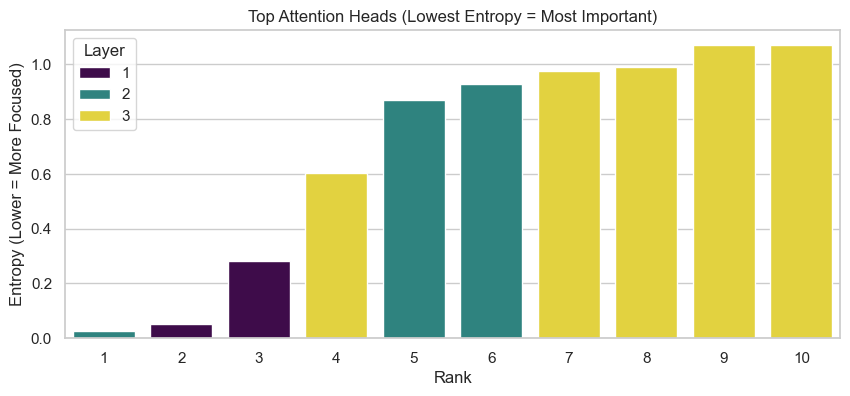

In [34]:
import seaborn as sns
plt.figure(figsize=(10,4))
sns.barplot(
    data=top_heads,
    x="Rank",
    y="Entropy",
    hue="Layer",
    palette="viridis"
)
plt.title("Top Attention Heads (Lowest Entropy = Most Important)")
plt.ylabel("Entropy (Lower = More Focused)")
plt.xlabel("Rank")
plt.legend(title="Layer")
plt.show()


## Summary: Attention-Based Interpretability

- Attention heatmaps show how RoBERTa focuses on key tokens.
- Last-layer heads often specialize in class-specific indicators.
- Layer-wise average attention reveals structural patterns.
- Attention entropy identifies the “important” heads.

This forms the second part of RQ3:  
**What linguistic or structural cues does the model use to differentiate AI vs Human text?**

Next section: **Attribution-based interpretability using Integrated Gradients.**


# 11. Attribution-Based Interpretability (Integrated Gradients)

While attention shows *where the model looks*, Integrated Gradients (IG) shows:

###  “Which input tokens *contribute to* the final prediction?”

IG is a gradient-based attribution method that:
- Computes how much each token influences the logit
- Provides signed importance scores (positive = AI class, negative = Human class)
- Works well for transformers (via Captum)

Computing:
- Token-level attributions
- Highlights of important words
- Comparison across examples
- Aggregated patterns across the entire dataset


In [39]:
from captum.attr import IntegratedGradients
import torch

def forward_embeds(embeds, attention_mask):
    outputs = model(
        inputs_embeds=embeds,
        attention_mask=attention_mask
    )
    # Logit of class 1 (AI)
    return outputs.logits[:, 1]


In [ ]:
def compute_ig_attributions(text, n_steps=50):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    # Converting input_ids to embeddings
    embeds = model.roberta.embeddings(input_ids)

    # Baseline: zero embeddings
    baseline = torch.zeros_like(embeds)

    ig = IntegratedGradients(forward_embeds)

    attributions, delta = ig.attribute(
        embeds,
        baselines=baseline,
        additional_forward_args=(attention_mask,),
        n_steps=n_steps,
        return_convergence_delta=True
    )

    # Converting tokens
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    # Reducing embedding-dimension attribution to per-token
    token_attributions = attributions.sum(dim=-1).detach().cpu().numpy()[0]

    return tokens, token_attributions, delta



# 12. Token-Level Attribution Visualization

Visualizing:
- Each token
- Its IG attribution value
- Whether it contributes *toward AI* or *toward Human*

Negative : pushes toward Human  
Positive : pushes toward AI


C:\Users\ajha26\AppData\Local\Temp\ipykernel_12228\2757279579.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tokens, y=attributions, palette="coolwarm")


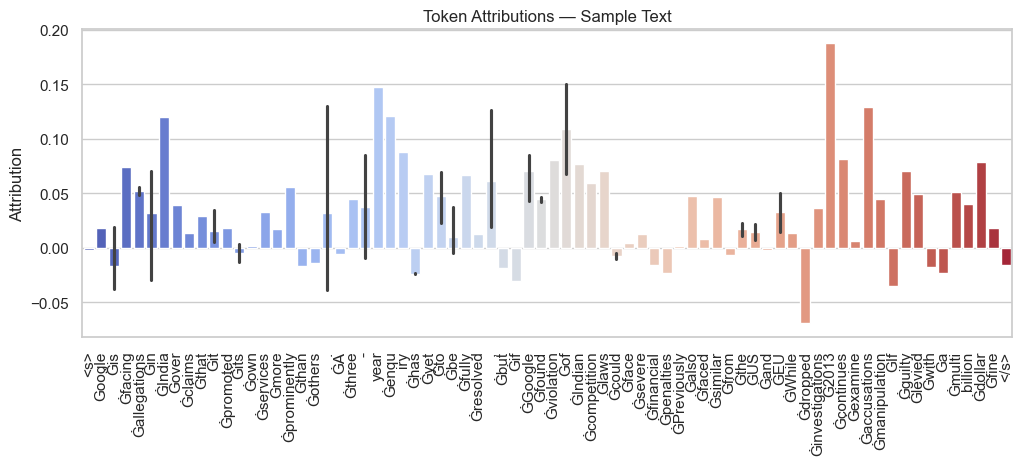

In [42]:
# Plotting Attributes for one text:

def plot_token_attributions(tokens, attributions, title="Attribution Scores"):
    plt.figure(figsize=(12,4))
    sns.barplot(x=tokens, y=attributions, palette="coolwarm")
    plt.xticks(rotation=90)
    plt.title(title)
    plt.ylabel("Attribution")
    plt.show()

# Example:
sample_text = test_df.sample(1).iloc[0]["text"]
tokens, atts, delta = compute_ig_attributions(sample_text)


plot_token_attributions(tokens, atts, title="Token Attributions — Sample Text")


# 13. Highlighting the Text by Attribution Strength

Creating a function that:
- Colors tokens red if they contribute to AI
- Colors tokens blue if they contribute to Human
- Intensity corresponds to magnitude

This is ideal to show qualitative examples.


In [ ]:
from IPython.display import HTML

def colorize(tokens, attributions, max_color=0.85):
    # Normalizing attributions
    norm = (attributions - attributions.min()) / (attributions.max() - attributions.min() + 1e-9)
    html = ""
    for tok, score in zip(tokens, norm):
        # map 0 → blue, 1 → red
        red = score
        blue = 1 - score
        html += f"<span style='background-color: rgba({255*red:.0f}, 0, {255*blue:.0f}, {max_color}); padding:2px; margin:2px;'>{tok}</span> "
    return HTML(html)

colorize(tokens, atts)


# 14. Token Attributions for 5 Random Samples

To understand qualitative patterns across the dataset,
Computing IG for 5 random texts from our test set.


In [46]:
import textwrap

samples = test_df.sample(5, random_state=99).reset_index(drop=True)

for i in range(5):
    text = samples.loc[i, "text"]
    label = samples.loc[i, "label"]

    print(f"\n\n===== SAMPLE {i+1} =====")
    print(f"True Label: {'AI' if label==1 else 'Human'}")
    print("\n--- Raw Text ---\n")
  
    print(textwrap.fill(text, width=120))
 
    tokens, atts, delta = compute_ig_attributions(text)

    print("\n--- Integrated Gradients Attribution (Colorized) ---\n")
    display(colorize(tokens, atts))





===== SAMPLE 1 =====
True Label: Human

--- Raw Text ---

Summer projects should be student-designed because students are busy during the summer and teachers make projects to
complicated.  One of the reasons why they should student-designed is that students are busy during the summer. Students
already go through so much during the school year, whether it be drama with another student, annoying teachers,
bullying, and even fights, so when school is over students just want to get away from it all. Most of the time students
will go see a parent, or go out of town, so they wonÃƒÂ‚Ã‚Â´t even have time to do a project.  My other reason is that
teachers make projects to complicated. Most teachers give projects at least twice a year, and one of the two will always
be to complicated to do. Teachers know that students go out of town during the summer, but they will still give you a
super complicated project just because youÃƒÂ‚Ã‚Â´ll have the whole summer to do it.  Some people might think tha



===== SAMPLE 2 =====
True Label: Human

--- Raw Text ---

If you get hit in a place that will knock you out , you 're getting knocked out . There 's no training for it . Boxers
train to not get hit by properly defending themselves with their hands . They also know how to take a punch , where they
can roll their head to minimize the impact of a hit . There 's no resistance to getting KO'd .

--- Integrated Gradients Attribution (Colorized) ---





===== SAMPLE 3 =====
True Label: AI

--- Raw Text ---

Is there any availability of online databases that store the financial statements of publicly traded enterprises?

--- Integrated Gradients Attribution (Colorized) ---





===== SAMPLE 4 =====
True Label: AI

--- Raw Text ---

Could you clarify the context or provide more information regarding the text to be paraphrased?

--- Integrated Gradients Attribution (Colorized) ---





===== SAMPLE 5 =====
True Label: Human

--- Raw Text ---

"The European perspective remains an extremely powerful instrument for the progress of reforms.

--- Integrated Gradients Attribution (Colorized) ---



# 15. Aggregated Attribution Patterns Across Entire Dataset

Computing:
- Top positive tokens → push prediction toward AI
- Top negative tokens → push prediction toward Human

This reveals dataset-wide lexical cues used by the model.


In [ ]:
from collections import defaultdict

token_scores = defaultdict(list)
N = 200  # number of samples to analyze

subset = test_df.sample(N, random_state=42).reset_index(drop=True)

for i in range(N):
    text = subset.loc[i, "text"]
    tokens, atts, delta = compute_ig_attributions(text)

    for tok, att in zip(tokens, atts):
        # skipping padding
        if tok in ["<pad>", "</s>", "<s>"]:
            continue
        token_scores[tok].append(att)

# Computing mean attribution per token
token_mean = {tok: np.mean(vals) for tok, vals in token_scores.items()}

# Converting to DataFrame
tok_df = pd.DataFrame({
    "token": list(token_mean.keys()),
    "mean_attr": list(token_mean.values())
})

# Separating by class influence
tok_ai = tok_df.sort_values("mean_attr", ascending=False).head(20)
tok_human = tok_df.sort_values("mean_attr", ascending=True).head(20)

tok_ai, tok_human


(            token  mean_attr
 3882           ĠQ   0.890375
 4163         tain   0.854093
 2125         What   0.819185
 1495    ĠCovenant   0.744839
 832          Ġret   0.658656
 2795           At   0.649151
 1498         ..."   0.553703
 3881            J   0.549504
 4048       Ġoverr   0.542915
 3345         Both   0.516648
 16          Ġpige   0.510488
 2839  ĠOpposition   0.489256
 2864        ained   0.467495
 25        Ġpigeon   0.422824
 2707  Ġpeacefully   0.417058
 840        Market   0.406443
 1665           ."   0.406368
 2594     Ġapplies   0.383257
 2652    Ġnotified   0.379472
 2250      Ġfridge   0.377338,
               token  mean_attr
 1933             16  -0.776583
 3744     Ġdiscussed  -0.699899
 1522      Ġendeavor  -0.374322
 4282             11  -0.341176
 472              An  -0.340810
 2653      Ġcarrying  -0.308807
 4061            Ġ).  -0.250886
 2790           ivid  -0.250789
 1477             Ġ6  -0.240332
 2310         Ġfluid  -0.240332
 3743         ĠOt

C:\Users\ajha26\AppData\Local\Temp\ipykernel_12228\3307265133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="mean_attr", y="token", data=tok_ai, palette="Reds_r")


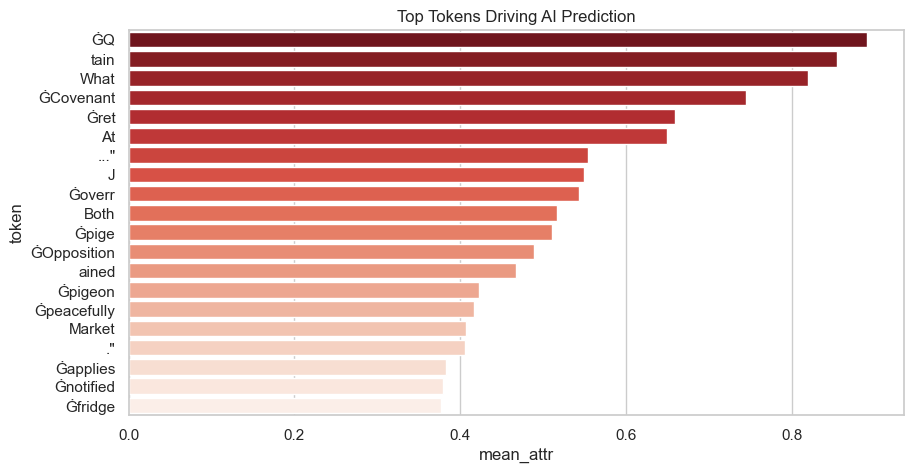

C:\Users\ajha26\AppData\Local\Temp\ipykernel_12228\3307265133.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="mean_attr", y="token", data=tok_human, palette="Blues_r")


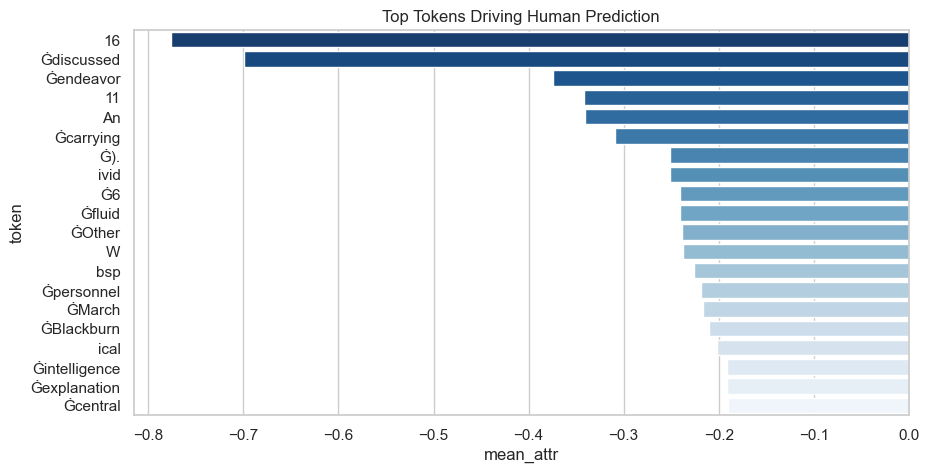

In [49]:
plt.figure(figsize=(10,5))
sns.barplot(x="mean_attr", y="token", data=tok_ai, palette="Reds_r")
plt.title("Top Tokens Driving AI Prediction")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x="mean_attr", y="token", data=tok_human, palette="Blues_r")
plt.title("Top Tokens Driving Human Prediction")
plt.show()


# 16. Saliency Maps (Gradient × Input)

A simpler alternative to IG:
- Computes token importance using gradient × input
- No integration steps → faster
- Slightly noisier

This strengthens interpretability.


In [51]:
saliency = Saliency(forward_embeds)



In [ ]:
def compute_saliency(text):
    encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    # Getting embeddings and make them leaf tensors
    embeds = model.roberta.embeddings(input_ids)
    embeds = embeds.detach().clone()
    embeds.requires_grad_(True)

    # Computing gradients w.r.t embeddings
    grads = saliency.attribute(
        embeds,
        additional_forward_args=(attention_mask,)
    )

    grads = grads.detach().cpu().numpy()[0]
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    # Reducing 768-dim gradients → per-token importance
    token_importance = grads.sum(axis=-1)

    return tokens, token_importance



C:\Users\ajha26\AppData\Local\Temp\ipykernel_12228\2757279579.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tokens, y=attributions, palette="coolwarm")


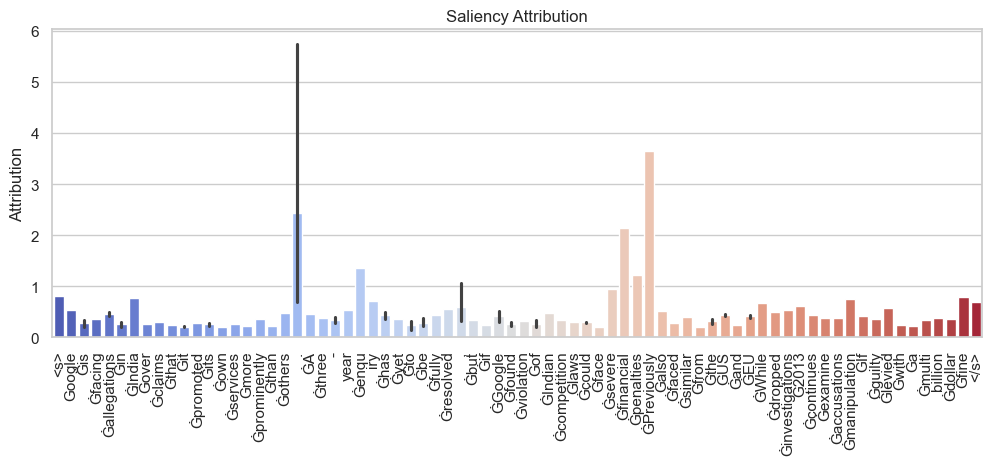

In [55]:
tokens_s, grads_s = compute_saliency(sample_text)
plot_token_attributions(tokens_s, grads_s, title="Saliency Attribution")


# 17. Error Analysis with Interpretability

This section identifies misclassified samples and uses Integrated Gradients,
attention maps, and saliency to understand *why* the model made mistakes.

Examining:
- False Positives (Human -- predicted AI)
- False Negatives (AI -- predicted Human)

These examples reveal linguistic patterns the model relies on and
highlight cases where those patterns fail.


In [57]:
def predict_logits(text_list):
    all_logits = []

    for text in text_list:
        encoded = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=256
        ).to(device)

        with torch.no_grad():
            outputs = model(
                input_ids=encoded["input_ids"],
                attention_mask=encoded["attention_mask"]
            )
        all_logits.append(outputs.logits.cpu().numpy()[0])

    return np.array(all_logits)


In [ ]:
# Getting logits for the entire test set
logits = predict_logits(test_df["text"].tolist())
y_pred = logits.argmax(axis=1)
y_true = np.array(test_df["label"])

# DataFrame with predictions
results_df = test_df.copy()
results_df["pred"] = y_pred
results_df["correct"] = (y_pred == y_true)

# Splitting error types
false_pos = results_df[(results_df["label"] == 0) & (results_df["pred"] == 1)]
false_neg = results_df[(results_df["label"] == 1) & (results_df["pred"] == 0)]

len(false_pos), len(false_neg)



(90, 60)

## 17.1 Interpreting False Positives

Examining Human-written text predicted as AI, using:
- Integrated Gradients (token attributions)
- Colorized explanation
- CLS-to-token attention heatmap



===== EXAMPLE =====
True Label: Human
Predicted: AI

--- Raw Text ---

(b) Ensure complete and accurate disclosure of non-expendable property and conduct physical stock checks on a regular
basis (1996, 1997, 1998 and 1999).

--- Integrated Gradients Attribution ---



--- Attention Heatmap (Layer 12, Head 0) ---


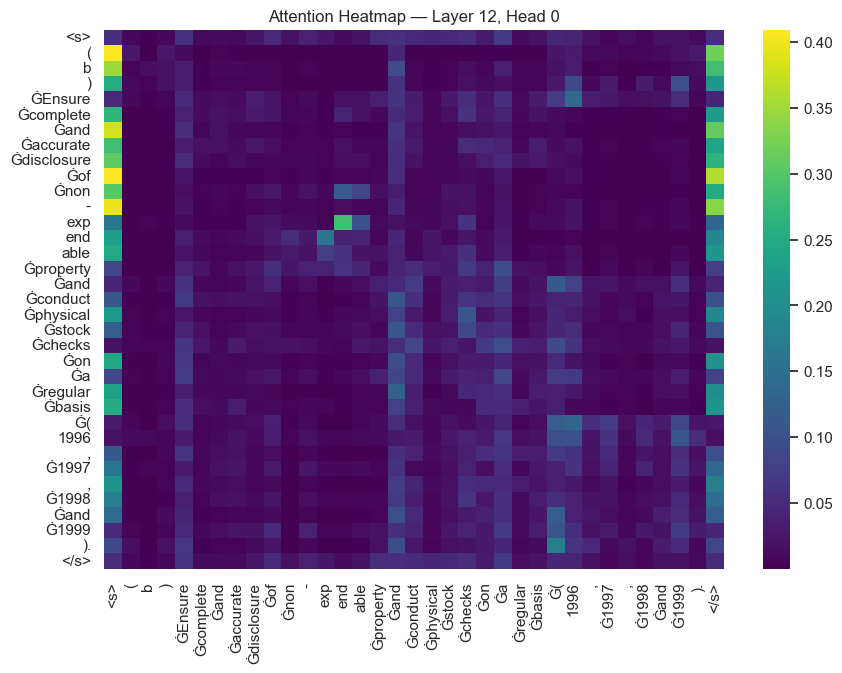


===== EXAMPLE =====
True Label: Human
Predicted: AI

--- Raw Text ---

The liability for defined benefit plans is measured at the present value of the defined benefit obligation.

--- Integrated Gradients Attribution ---



--- Attention Heatmap (Layer 12, Head 0) ---


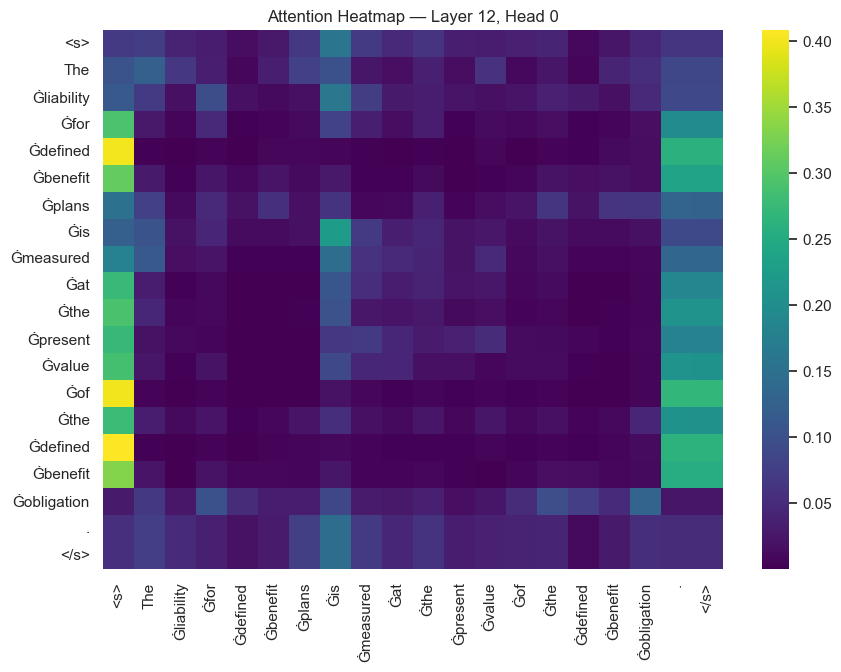


===== EXAMPLE =====
True Label: Human
Predicted: AI

--- Raw Text ---

A third potential explanation is that intelligence is about good decision-making.

--- Integrated Gradients Attribution ---



--- Attention Heatmap (Layer 12, Head 0) ---


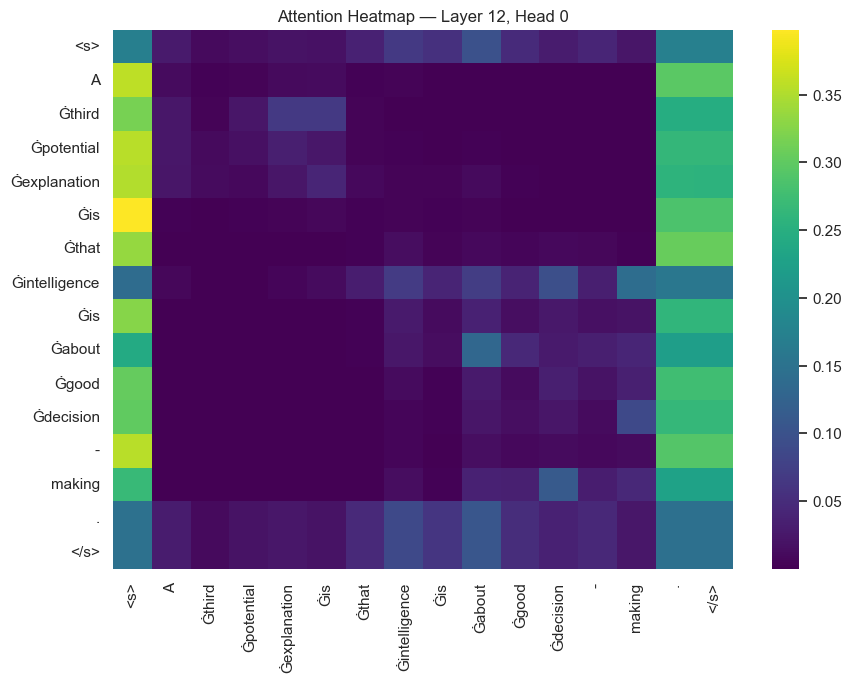

In [ ]:
import textwrap

def explain_example(text, true_label, pred_label):
    print(f"\n===== EXAMPLE =====")
    print(f"True Label: {'AI' if true_label==1 else 'Human'}")
    print(f"Predicted: {'AI' if pred_label==1 else 'Human'}")

    print("\n--- Raw Text ---\n")
    print(textwrap.fill(text, width=120))

    print("\n--- Integrated Gradients Attribution ---")
    tokens, atts, delta = compute_ig_attributions(text)
    display(colorize(tokens, atts))

    print("\n--- Attention Heatmap (Layer 12, Head 0) ---")

    att, toks = get_attention_for_text(model, tokenizer, text)

    layer = -1   # last layer
    head = 0     # head 0

    layer_att = att[layer]

    # Handling shapes:
    # possible shapes:
    # (1, 12, seq, seq)
    # (12, seq, seq)
    # (1, seq, seq)  <-- averaged heads case
    if layer_att.dim() == 4:
        layer_att = layer_att[0]  # removing batch dimension

    if layer_att.dim() == 3 and layer_att.shape[0] > 1:
        head_att = layer_att[head]  # picking specific head
    else:
        # already averaged → shape (seq, seq)
        head_att = layer_att

    plt.figure(figsize=(10,7))
    sns.heatmap(
        head_att.detach().cpu().numpy(),
        xticklabels=toks,
        yticklabels=toks,
        cmap="viridis"
    )
    plt.xticks(rotation=90)
    plt.title(f"Attention Heatmap — Layer 12, Head {head}")
    plt.show()


# Taking 3 false positives
fp_samples = false_pos.sample(min(3, len(false_pos)), random_state=42)

for i, row in fp_samples.iterrows():
    explain_example(row["text"], row["label"], row["pred"])

## 17.2 Interpreting False Negatives

Now analyzing AI-generated text predicted as Human.



===== EXAMPLE =====
True Label: AI
Predicted: Human

--- Raw Text ---

There are thousands of such students who have the impression that history is a string of dates, that mathematics is the
most exhausting thing for their unripe minds.

--- Integrated Gradients Attribution ---



--- Attention Heatmap (Layer 12, Head 0) ---


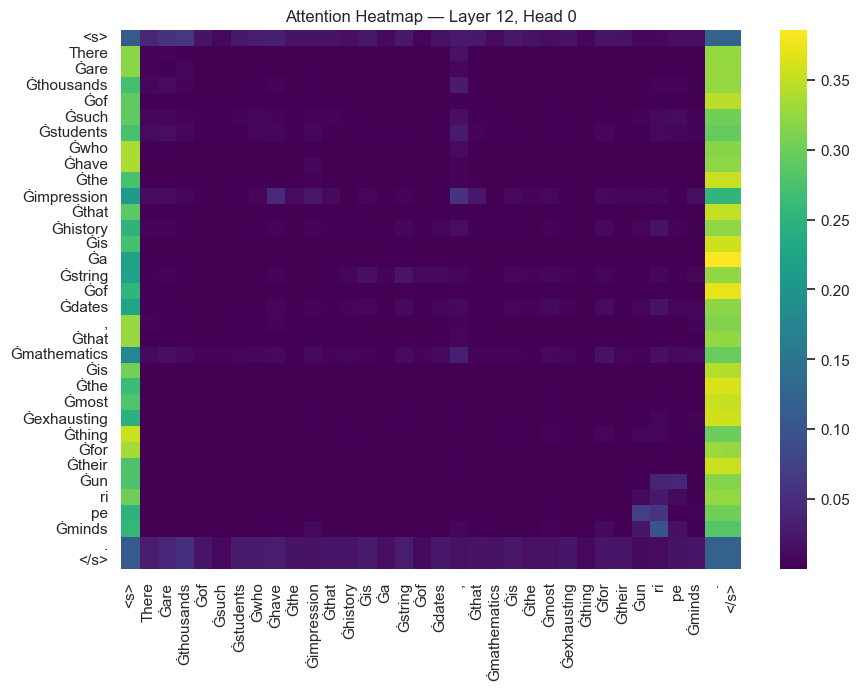


===== EXAMPLE =====
True Label: AI
Predicted: Human

--- Raw Text ---

Aufmerksame Besitzer, gute Zimmerausstattung und eine ideale Lage fÃ¼r uns, ParkplÃ¤tze, gutes FrÃ¼hstÃ¼ck. Wir werden
wieder besuchen. Das Zimmer war schÃ¶n und warm fÃ¼r einen Herbstbesuch. Das Hotel war Ã¼berraschend grÃ¶ÃŸer als wir
uns vorgestellt hatten.  Attentive owners, good room facilities and an ideal location for us, car parking spaces,
filling breakfast. We will visit again. Room was nice and warm for an autumn visit. Hotel was surprisingly larger than
we imagined.

--- Integrated Gradients Attribution ---



--- Attention Heatmap (Layer 12, Head 0) ---


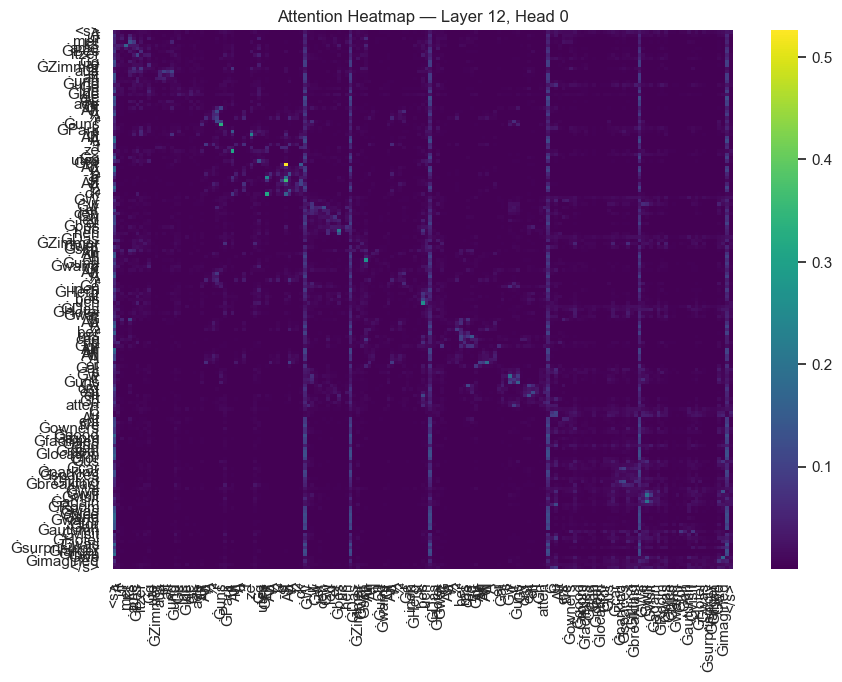


===== EXAMPLE =====
True Label: AI
Predicted: Human

--- Raw Text ---

Do the regulations for wash sales vary between stocks and ETFs / Mutual Funds?

--- Integrated Gradients Attribution ---



--- Attention Heatmap (Layer 12, Head 0) ---


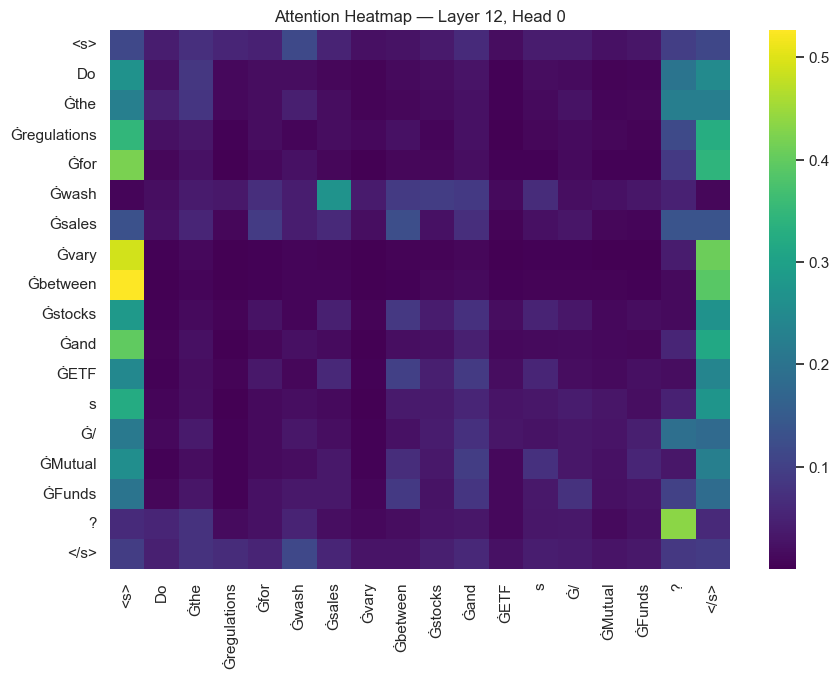

In [67]:
fn_samples = false_neg.sample(min(3, len(false_neg)), random_state=42)

for i, row in fn_samples.iterrows():
    explain_example(row["text"], row["label"], row["pred"])


# GLOBAL TOKEN IMPORTANCE (Corpus-Level IG Aggregation)

This computes Integrated Gradients for N random samples from the test set, aggregates attribution scores per token, and shows which tokens the transformer relies on globally.

In [ ]:
import numpy as np
from collections import defaultdict

def aggregate_token_attributions(model, tokenizer, df, n_samples=200):
    """
    Computes IG attributions for n_samples and aggregates per-token importance.
    """
    df = df.sample(n_samples, random_state=42).reset_index(drop=True)

    token_importance = defaultdict(list)

    for i, text in df["text"].items():
        try:
            tokens, atts, _ = compute_ig_attributions(text)
            for tok, att in zip(tokens, atts):
                token_importance[tok].append(att)
        except Exception as e:
            print("Error on sample", i, ":", e)

    # Computing mean attribution per token
    token_stats = {
        tok: np.mean(vals) for tok, vals in token_importance.items()
        if len(vals) > 1
    }

    return token_stats


In [69]:
token_stats = aggregate_token_attributions(model, tokenizer, test_df, n_samples=200)

len(token_stats)


2061

In [70]:
# top 25 most important tokens:

import pandas as pd

top_tokens = (
    pd.Series(token_stats)
    .sort_values(ascending=False)
    .head(25)
)

top_tokens


."             0.406368
Ġclubs         0.372096
['             0.365587
Ġr             0.363075
["             0.324130
.'             0.313957
Ġclouds        0.263500
]              0.251174
Ġespecially    0.192271
ors            0.190926
making         0.171096
Ġpictures      0.170689
Imagine        0.170420
Ġconcern       0.168090
Ġthird         0.167586
Ġwhilst        0.167397
ĠEven          0.166871
th             0.166097
ĠNewcastle     0.164710
A              0.162940
Ġnarrow        0.162624
Ġaddition      0.160308
"              0.159766
160            0.159540
out            0.158608
dtype: float32

C:\Users\ajha26\AppData\Local\Temp\ipykernel_12228\1776187008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tokens.values, y=top_tokens.index, palette="coolwarm")


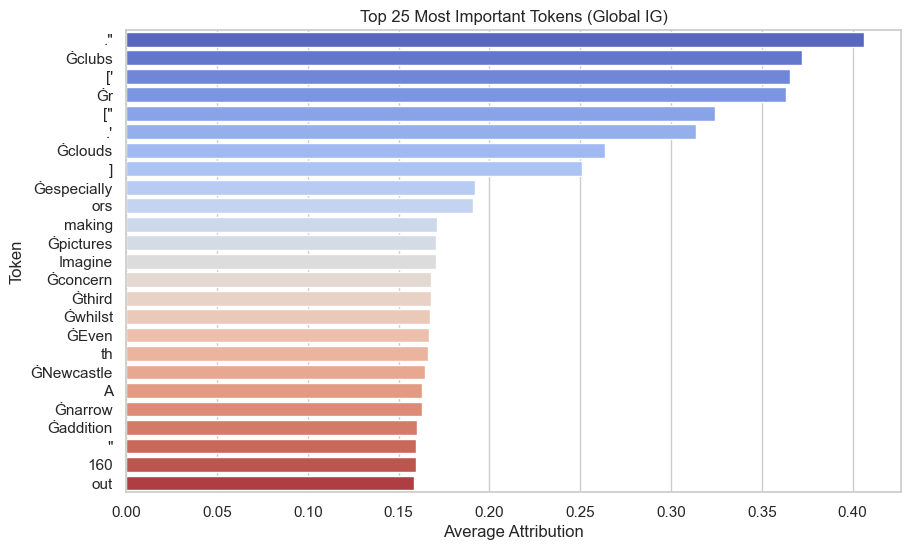

In [71]:
# plotting token importances:

plt.figure(figsize=(10,6))
sns.barplot(x=top_tokens.values, y=top_tokens.index, palette="coolwarm")
plt.title("Top 25 Most Important Tokens (Global IG)")
plt.xlabel("Average Attribution")
plt.ylabel("Token")
plt.show()


# GLOBAL ATTENTION ENTROPY (Which Heads Are Most Focused?)

This measures attention entropy for each head across many examples -- which heads are “sharper” and more discriminative.

In [72]:
def compute_head_entropy(attentions):
    """
    attentions: list of tensors (layers) → shape: (num_heads, seq, seq)
    Returns: entropy matrix (layers x heads)
    """
    entropies = []

    for layer_att in attentions:
        layer_ent = []
        for head_att in layer_att:  # shape: (seq, seq)
            p = head_att.detach().cpu().numpy()
            p = np.clip(p, 1e-9, 1)
            p = p / p.sum(axis=-1, keepdims=True)
            ent = -(p * np.log(p)).sum(axis=-1).mean()
            layer_ent.append(ent)
        entropies.append(layer_ent)

    return np.array(entropies)  # shape (layers, heads)


In [73]:
def compute_global_attention_entropy(model, tokenizer, df, n_samples=100):
    df = df.sample(n_samples, random_state=42)
    entropies = []

    for text in df["text"]:
        att, _ = get_attention_for_text(model, tokenizer, text)
        e = compute_head_entropy(att)  # (12 layers, 12 heads)
        entropies.append(e)

    entropies = np.stack(entropies)  # (samples, layers, heads)
    return entropies.mean(axis=0), entropies.std(axis=0)

entropy_mean, entropy_std = compute_global_attention_entropy(
    model, tokenizer, test_df, n_samples=100
)


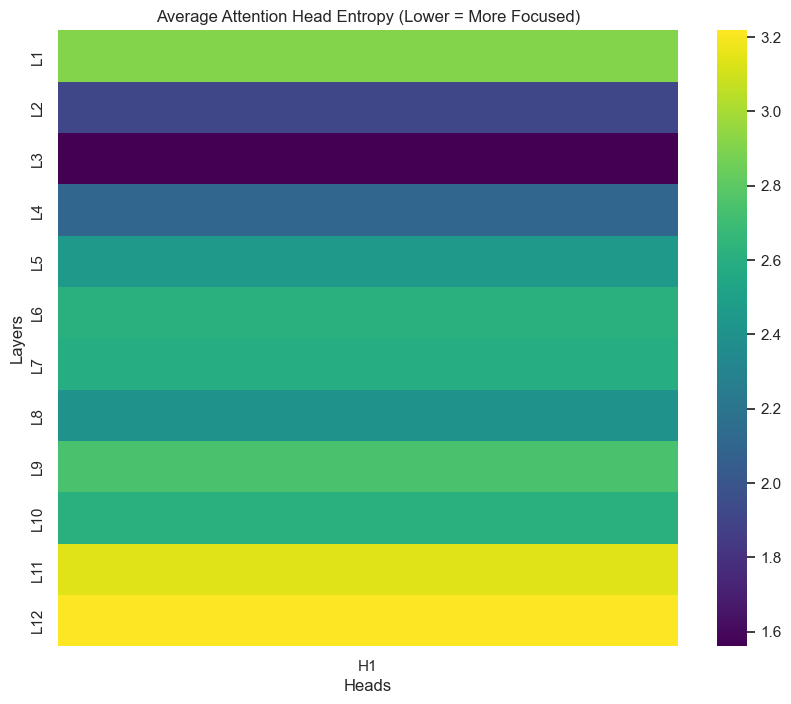

In [74]:
plt.figure(figsize=(10,8))
sns.heatmap(
    entropy_mean,
    cmap="viridis",
    annot=False,
    xticklabels=[f"H{h+1}" for h in range(entropy_mean.shape[1])],
    yticklabels=[f"L{l+1}" for l in range(entropy_mean.shape[0])]
)
plt.title("Average Attention Head Entropy (Lower = More Focused)")
plt.xlabel("Heads")
plt.ylabel("Layers")
plt.show()


# Calibration Curve & Model Confidence Analysis

This shows whether the model is overconfident.

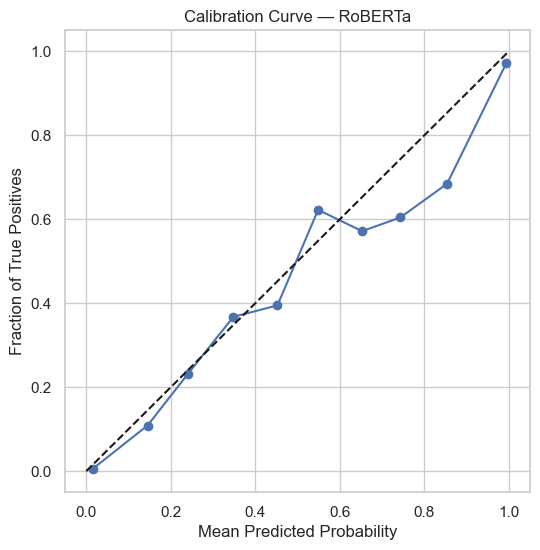

In [77]:
from sklearn.calibration import calibration_curve

probs = torch.softmax(torch.tensor(logits), dim=1)[:,1].numpy()

fraction_pos, mean_pred = calibration_curve(y_true, probs, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(mean_pred, fraction_pos, marker='o')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of True Positives")
plt.title("Calibration Curve — RoBERTa")
plt.grid(True)
plt.show()


In [78]:
def compute_ece(y_true, probs, n_bins=15):
    bins = np.linspace(0,1,n_bins+1)
    ece = 0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() > 0:
            acc = y_true[mask].mean()
            conf = probs[mask].mean()
            ece += (mask.sum()/len(probs)) * abs(acc - conf)
    return ece

ece = compute_ece(y_true, probs)
ece


np.float64(0.025503058243542924)

#### FINAL GLOBAL MODEL SUMMARY

In [94]:
print("===== GLOBAL MODEL SUMMARY =====")

print("\nTop Global Tokens (IG):")
print(top_tokens)

print("\nLowest Entropy Heads (most focused):")
low_ent = np.unravel_index(np.argsort(entropy_mean, axis=None), entropy_mean.shape)
for idx in zip(low_ent[0][:5], low_ent[1][:5]):
    print(f"Layer {idx[0]+1}, Head {idx[1]+1}, Entropy={entropy_mean[idx]:.4f}")

print("\nECE (Calibration Error):", round(ece, 4))
print("Model is overconfident!" if ece > 0.05 else "Model is well calibrated.")


===== GLOBAL MODEL SUMMARY =====

Top Global Tokens (IG):
."             0.406368
Ġclubs         0.372096
['             0.365587
Ġr             0.363075
["             0.324130
.'             0.313957
Ġclouds        0.263500
]              0.251174
Ġespecially    0.192271
ors            0.190926
making         0.171096
Ġpictures      0.170689
Imagine        0.170420
Ġconcern       0.168090
Ġthird         0.167586
Ġwhilst        0.167397
ĠEven          0.166871
th             0.166097
ĠNewcastle     0.164710
A              0.162940
Ġnarrow        0.162624
Ġaddition      0.160308
"              0.159766
160            0.159540
out            0.158608
dtype: float32

Lowest Entropy Heads (most focused):
Layer 3, Head 1, Entropy=1.5609
Layer 2, Head 1, Entropy=1.9117
Layer 4, Head 1, Entropy=2.1055
Layer 8, Head 1, Entropy=2.4045
Layer 5, Head 1, Entropy=2.4529

ECE (Calibration Error): 0.0255
Model is well calibrated.


In [95]:
import os

save_root = r"C:\Users\ajha26\Desktop\IS\Results\Transformer_Interpretability"

os.makedirs(save_root, exist_ok=True)
print("Saving all outputs to:", save_root)


Saving all outputs to: C:\Users\ajha26\Desktop\IS\Results\Transformer_Interpretability


In [96]:
import numpy as np

np.save(os.path.join(save_root, "test_embeddings.npy"), test_embeddings)
print("Saved test embeddings.")


Saved test embeddings.


In [97]:
tsne_df.to_csv(os.path.join(save_root, "tsne_embeddings.csv"), index=False)
umap_df.to_csv(os.path.join(save_root, "umap_embeddings.csv"), index=False)

print("Saved TSNE + UMAP embeddings.")


Saved TSNE + UMAP embeddings.


In [98]:
plt.figure(figsize=(7,6))
sns.scatterplot(x="x", y="y", hue="label", data=tsne_df, palette="coolwarm", alpha=0.7)
plt.title("t-SNE Embedding Visualization")
plt.savefig(os.path.join(save_root, "tsne_plot.png"), dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(7,6))
sns.scatterplot(x="x", y="y", hue="label", data=umap_df, palette="coolwarm", alpha=0.7)
plt.title("UMAP Embedding Visualization")
plt.savefig(os.path.join(save_root, "umap_plot.png"), dpi=300, bbox_inches="tight")
plt.close()

print("Saved TSNE + UMAP plots.")


Saved TSNE + UMAP plots.


In [99]:
pd.Series(token_stats, name="IG_score").to_csv(
    os.path.join(save_root, "global_token_importance.csv")
)
print("Saved global token importance table.")


Saved global token importance table.


In [100]:
np.save(os.path.join(save_root, "head_entropy_mean.npy"), entropy_mean)
np.save(os.path.join(save_root, "head_entropy_std.npy"), entropy_std)

print("Saved global attention entropy matrices.")


Saved global attention entropy matrices.


In [101]:
plt.figure(figsize=(10,8))
sns.heatmap(
    entropy_mean,
    cmap="viridis",
    xticklabels=[f"H{h+1}" for h in range(entropy_mean.shape[1])],
    yticklabels=[f"L{l+1}" for l in range(entropy_mean.shape[0])]
)
plt.title("Average Attention Head Entropy")
plt.savefig(os.path.join(save_root, "attention_entropy_heatmap.png"),
            dpi=300, bbox_inches="tight")
plt.close()

print("Saved entropy heatmap.")


Saved entropy heatmap.


In [102]:
plt.figure(figsize=(6,6))
plt.plot(mean_pred, fraction_pos, marker='o')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of True Positives")
plt.title("Calibration Curve")
plt.grid(True)

plt.savefig(os.path.join(save_root, "calibration_curve.png"),
            dpi=300, bbox_inches="tight")
plt.close()

print("Saved calibration curve.")


Saved calibration curve.


In [103]:
with open(os.path.join(save_root, "ECE.txt"), "w") as f:
    f.write(f"Expected Calibration Error (ECE): {ece:.6f}")

print("Saved ECE value.")


Saved ECE value.


In [104]:
false_pos.to_csv(os.path.join(save_root, "false_positives.csv"), index=False)
false_neg.to_csv(os.path.join(save_root, "false_negatives.csv"), index=False)

print("Saved FP & FN samples.")


Saved FP & FN samples.


In [105]:
ig_dir = os.path.join(save_root, "IG_Samples")
os.makedirs(ig_dir, exist_ok=True)

for i in range(5):
    text = samples.loc[i, "text"]
    label = samples.loc[i, "label"]

    tokens, atts, delta = compute_ig_attributions(text)
    html = colorize(tokens, atts)  # already built earlier

    with open(os.path.join(ig_dir, f"sample_{i+1}.html"), "w", encoding="utf-8") as f:
        f.write(str(html))

print("Saved IG example visualizations.")


Saved IG example visualizations.
